# Assignment 4 Solution

- Name: Kenji Otsuka
- Email: kotsuka@umich.edu

In this assignment, I created four notebooks: fitparse_csv_creation.ipynb, EDA.ipynb, this notebook, and dashboard.ipynb.
fitparse_csv_creation.ipynb is used to generate a dataframe from .fit files and to inspect the units of each feature.
EDA.ipynb is used to get an overview of the dataset and perform preprocessing.
All activities are categorized into cycling and running within EDA.ipynb. dashboard.ipynb is created for convenience to see dashboard. The dashboard is also in this notebook but it requires running all the cells.

I used line chart, violin plot, barchart, heatmap and scatter plot as basic visualizations, and I used 3D scatter plot as an advanced visualization.

## 1. Introduction and Adherence to Design Rules

This notebook analyzes Dr. Brooks' running data over time.
The goal is to evaluate overall performance trends and identify key factors to further enhance his running efficiency.

### Adherence to Rule et al.'s "Ten Simple Rules for Writing and Sharing Computational Analyses in Jupyter Notebooks"

#### Rule 1: Tell a Story for an Audience

This notebook explains how Professor Brooks' running performance has changed over time.
Each section provides not just the calculations, but also the practical context behind them.
The statements contains technical detail and insights.

#### Rule 2: Document the Process, Not Just the Results

I documented intermediate steps, exploratory attempts, and reasoning behind parameter choices in addition to the final results.
I included short markdown notes that describe why a particular approach was tried and what insights it provided.

#### Rule 3: Use Cell Divisions to Make Steps Clear

Each cell performs one meaningful step of the analysis, such as loading data, computing a statistic, generating a plot, or performing clustering.
Markdown headers divide the notebook into clear sections (e.g., preprocessing, exploratory analysis, correlation analysis, clustering), and each cell is preceded by a short explanation of its purpose.


## 2. Data Loading & Preprocessing

The dataset is combined and briefly analyzed in advance in another notebook, .

Here, we load the preprocessed data. Since we are analyzing running machines, we will:

1. Filter the dataset to only include running. In other words, exclude cycling data.
2. Append the new feature column, Running Effectiveness (from1runner2another, 2026), to investigate running improvement. It is calculated as speed / power.
3. Convert timestamp field value type to datetime.
4. Create session_index that represents the sequential order of workouts.
3. Filter the dataset using logical biomechanical thresholds. The following conditions are easily sufficed when running.
    - Form Power > 0 (W)
    - Speed > 1.0 (m/s)
    - Power > 50 (W) 
    - Cadence > 50 (RPM)
    - 0 \< Ground Time \< 1000 (ms)


In [1]:
import sys

try:
    import hdbscan
except:
    !python -m pip install --target=$HOME/.local "hdbscan<0.8.40"
    sys.path.append("/voc/work/.local")
    import hdbscan


  Using cached hdbscan-0.8.39-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (15 kB)
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached hdbscan-0.8.39-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.4 MB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached narwhals-2.24.0-py3

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets

In [3]:
df = pd.read_csv("csv_output/preprocessed.csv")
df.rename(columns={'enhanced_speed':'Speed','cadence':'Cadence'}, inplace=True)
df['Running Effectiveness'] = df['Speed'] / df['Power']

In [4]:
df.shape

(529985, 18)

In [5]:
df.columns

Index(['Cadence', 'distance', 'enhanced_altitude', 'Speed',
       'fractional_cadence', 'heart_rate', 'position_lat', 'position_long',
       'timestamp', 'source_file', 'Ground Time', 'Power',
       'Vertical Oscillation', 'Air Power', 'Form Power',
       'Leg Spring Stiffness', 'activity_type', 'Running Effectiveness'],
      dtype='object')

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['session_index'] = df['source_file'].rank(method='dense').astype(int)

In [7]:
run_df = df[df['activity_type'] == 'running']
run_df = run_df[
    (run_df['Form Power'] > 0) & \
    (run_df['Speed'] > 1.0) & \
    (run_df['Power'] > 50) & \
    (run_df['Cadence'] > 50) & \
    (run_df['Ground Time'] < 1000) & \
    (run_df['Ground Time'] > 0)
]


## 3. Grasp Trend Overview

See the chart of running related features and grasp the trends.
To show the trends, we use median values of each sessions.
X-axis in the charts is session index of excercises.
It starts from 0.
(Using calendar dates on the x‑axis creates uneven spacing because training sessions are not performed at regular intervals.
It may create clusters and gaps, which distort the visual trend.
So I used sequential session index.)

In [8]:
grouped_metrics = run_df.groupby(['source_file', 'session_index', "activity_type"]).agg({
    "Cadence": ["min", "median", "max"],
    "Speed": ["min", "median", "max"],
    "Leg Spring Stiffness": ["min", "median", "max"],
    "timestamp": ["min", "max"],
    "distance": ["max"],
    "heart_rate": ["min", "median", "max"],
    "Power": ["min", "median", "max"],
    "Vertical Oscillation": ["min", "median", "max"],
    "Form Power": ["min", "median", "max"],
    "Air Power": ["min", "median", "max"],
    "Ground Time": ["min", "median", "max"],
    "Running Effectiveness": ["min", "median", "max"],
})

In [9]:
# Set clean aesthetic for plots 
sns.set_theme(style="whitegrid")

In [10]:
grouped_metrics=grouped_metrics.reset_index()

In [11]:
UNITS = {
    'Running Effectiveness': None,
    'Speed': 'm/s',
    'Cadence': 'RPM',
    'Ground Time': 'ms',
    'Form Power': 'W',
    'Power': 'W',
    'Leg Spring Stiffness': 'kN/m' 
}
features = [
    'Running Effectiveness',
    'Speed',
    'Cadence',
    None,
    'Ground Time',
    'Form Power',
    'Power',
    'Leg Spring Stiffness'
]

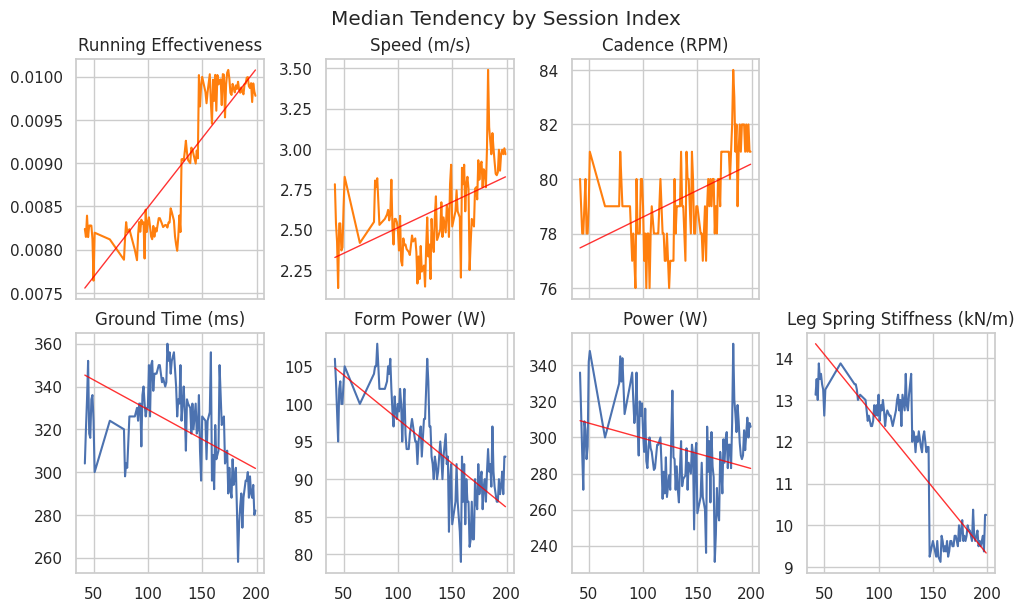

In [12]:
run_group_df = grouped_metrics[grouped_metrics['activity_type'] == 'running']
plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['figure.figsize'] = (10, 8)

def add_regression_line(ax, x, y, color="red"):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    slope, intercept = np.polyfit(x_clean, y_clean, 1)

    x_vals = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_vals = slope * x_vals + intercept

    ax.plot(x_vals, y_vals, color=color, linewidth=1, alpha=0.8)

plt.rcParams['figure.figsize'] = (10, 6)

fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(
    2, 4,
    # hspace=0.1
)
axs = gs.subplots(sharex=True, sharey=False)
fig.suptitle(
    "Median Tendency by Session Index",
    # y=1.05
) 
x = grouped_metrics['timestamp']['min']
x = grouped_metrics['session_index']
positive_color = '#ff7f0e'
negative_color = '#1f77b4'

axs[0, 0].set_title('Running Effectiveness')
axs[0, 0].plot(x, grouped_metrics['Running Effectiveness']['median'], color=positive_color)
add_regression_line(axs[0, 0], x, grouped_metrics['Running Effectiveness']['median'])

axs[0, 1].set_title('Speed (m/s)')
axs[0, 1].plot(x, grouped_metrics['Speed']['median'], color=positive_color)
add_regression_line(axs[0, 1], x, grouped_metrics['Speed']['median'])

axs[0, 2].set_title('Cadence (RPM)')
axs[0, 2].plot(x, grouped_metrics['Cadence']['median'], color=positive_color)
add_regression_line(axs[0, 2], x, grouped_metrics['Cadence']['median'])


axs[0, 3].axis("off")
# axs[2, 2].axis("off")

axs[1, 0].set_title('Ground Time (ms)')
axs[1, 0].plot(x, grouped_metrics['Ground Time']['median'])
add_regression_line(axs[1, 0], x, grouped_metrics['Ground Time']['median'])

axs[1, 1].set_title('Form Power (W)')
axs[1, 1].plot(x, grouped_metrics['Form Power']['median'])
add_regression_line(axs[1, 1], x, grouped_metrics['Form Power']['median'])

axs[1, 2].set_title('Power (W)')
axs[1, 2].plot(x, grouped_metrics['Power']['median'])
add_regression_line(axs[1, 2], x, grouped_metrics['Power']['median'])

axs[1, 3].set_title('Leg Spring Stiffness (kN/m)')
axs[1, 3].plot(x, grouped_metrics['Leg Spring Stiffness']['median'])
add_regression_line(axs[1, 3], x, grouped_metrics['Leg Spring Stiffness']['median'])


I found the running effectiveness become better and several related values changed at the same time.

- increase
  - Cadence
  - Speed
- decrease
  - Ground Time
  - Power
  - Form Power
  - Leg Spring Stiffness

(Leg Spring Stiffness is an estimation based on other values. enhanced_speed is a result. So I will focus other values.)

## 4. See Trends in Violine Chart

The line charts show the tendency of median values.
Then we'll confirm the change is valid with all the data.
To show season trends clearly, we split the data into 3 terms and plot them with violine plot with quater lines.

See actual datetime range:

In [13]:
df['timestamp'].min(), df['timestamp'].max()

(Timestamp('2019-07-08 21:04:03'), Timestamp('2020-10-15 12:30:42'))

The data contains from 2019-07-06 to 2020-10-15,
then we split the data as:

- Term 1 : 2019-07 - 2019-12
- Term 2 : 2020-01 - 2020-06
- Term 3 : 2020-07 - 2020-08

In [14]:
bins = [
    datetime(2019, 7, 1),
    datetime(2020, 1, 1),
    datetime(2020, 7, 1),
    datetime(2020, 12, 1)
]
labels = [
    'Term 1',
    'Term 2',
    'Term 3',
]
run_df['term'] = pd.cut(run_df['timestamp'], bins=bins, labels=labels)
# run_df['term'].value_counts()
# run_df[['term', 'source_file']].drop_duplicates()['term'].value_counts()

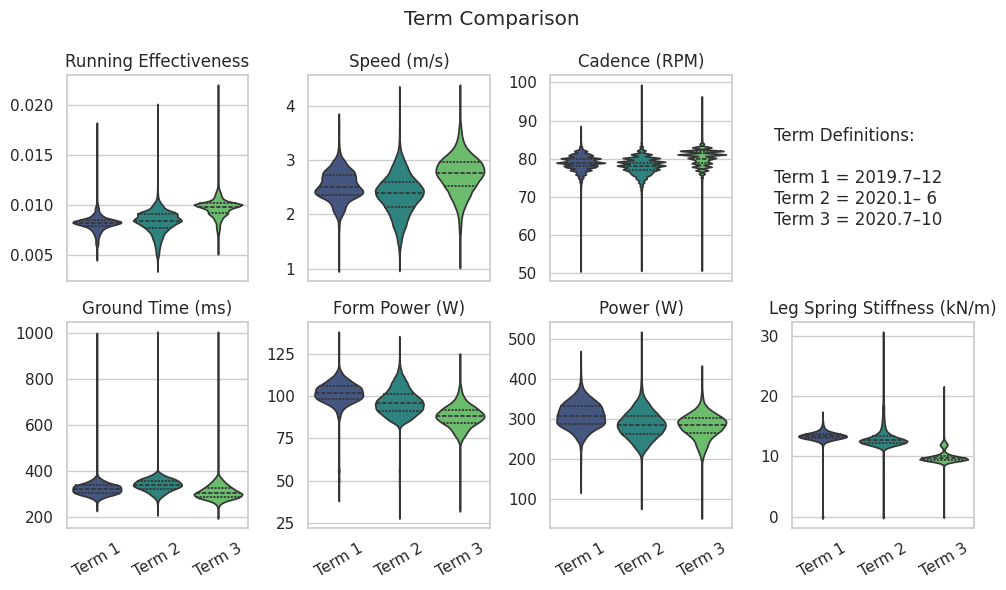

In [15]:

fig = plt.figure()
plt.rcParams['figure.figsize'] = (10, 8)

gs = fig.add_gridspec(2, 4)
axs = gs.subplots(sharex=True, sharey=False)
fig.suptitle("Term Comparison") 

for i in range(2):
    for j in range(4):
        feature = features[i * 4 + j]
        if feature is None:
            axs[i, j].axis("off")
            axs[i, j].text(
                -0.8, 0.5,
                "Term Definitions:\n\n"
                "Term 1 = 2019.7–12\n"
                "Term 2 = 2020.1– 6\n"
                "Term 3 = 2020.7–10",
                ha='left', va='center',
                fontsize=12
            )
            continue
        sns.violinplot(
            data=run_df,
            x='term',
            y=feature,
            palette='viridis',
            hue='term',
            dodge=False,
            inner="quartile",
            legend=False,
            ax=axs[i, j]
        )
        axs[i, j].set_ylabel('')
        axs[i, j].set_xlabel('')
        axs[i, j].set_title(
            feature if UNITS[feature] is None else f"{feature} ({UNITS[feature]})"
        )
        if i == 1:
            axs[i, j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Based on the violin plots,
**Running Effectiveness**, **Form Power**, and **Leg Spring Stiffness** **show clear and consistent trends**
across the three terms.

- Running Effectiveness increases
- Form Power decreases
- Leg Spring Stiffness decreases

These changes indicate improvements in running efficiency and stability.

In contrast, **cadence**, **enhanced_speed**, and **Ground Time** **do not show fully consistent trends**.

- From the first term to the second term, their changes are small or even opposite in direction.
- From the second term to the third term, they show clearer improvement.
- As a result,  **the overall first -\> third term change is positive**, but **the intermediate trend is not consistent**.

Regarding **Power**, it decreases from the first term to the second term, but it did not radically change from the second term to the third term. 

This suggests that these metrics improved gradually and non-linearly,
rather than showing a steady, monotonic progression.

## 5. Correlation

Now we know the trends with all data.
Let's see how strong those trends affects each other,
and see what the strongly related feature to Running Effective is.

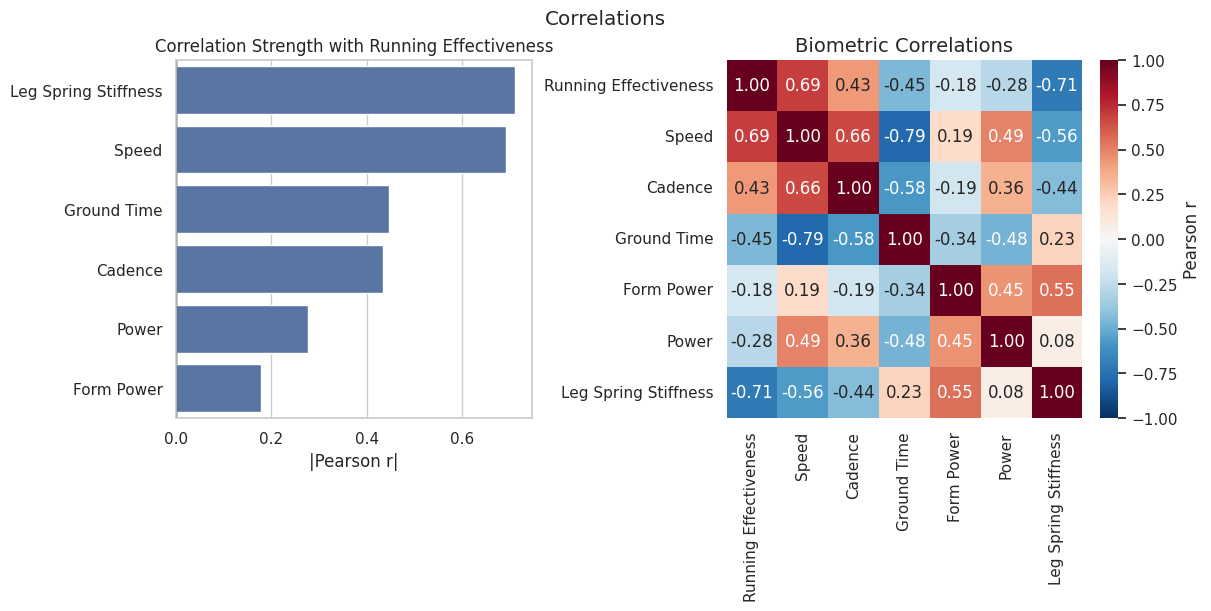

In [16]:
plt.rcParams['figure.figsize'] = (12, 6)
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(1, 2)
axs = gs.subplots(sharex=False, sharey=False)

# fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlations")
corr_features = [
    'Running Effectiveness',
    'Speed',
    'Cadence',
    'Ground Time',
    'Form Power',
    'Power',
    'Leg Spring Stiffness'
]
corr_matrix = run_df[corr_features].corr()

top_features = corr_matrix['Running Effectiveness'].drop('Running Effectiveness')
top_features = top_features.abs()
top_features = top_features.sort_values(ascending=False)

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    ax=axs[0]
)
axs[0].axvline(0, color='black', linewidth=1)
axs[0].set_title('Correlation Strength with Running Effectiveness')
axs[0].set_xlabel('|Pearson r|')
axs[0].set_ylabel('')

sns.heatmap(
    corr_matrix, annot=True, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, fmt=".2f",
    cbar_kws={'label': 'Pearson r'},
    ax=axs[1]
)
axs[1].set_title("Biometric Correlations", fontsize=14)
plt.show()


The correlation heatmap shows that
**Running Effectiveness** has a strong correlation with **Leg Spring Stiffness** and **Speed**,
and moderate correlation with **Ground Time** and **Cadence**.

Cadence and Speed show weaker correlations,
consistent with the non-linear and gradual changes observed in the violin plots.

Form Power that shows strong declining tendency does not correlate to Running Effectiveness.

Based on these correlations, I used scatter plots to see the shape and structure of these relationships.

# 6. Actual Distribution

We know the trends and correlations with all data, but they are just superficial.
We don't know the actual distribution, yet.

Let's see feature value distributions.
Especially, we focus the variables which runners can control.

Leg Spring Stiffness or Cadence is not included.
Leg Spring Stiffness is an estimate value.
Cadence is changed along with Ground Time and Speed.

Then, the plots I create are:

- Form related variables
    - Form Power x Ground Time（color = Running Effectiveness）
    - Form Power x Speed（color = Running Effectiveness）
    - Ground Time x Speed（color = Running Effectiveness)
- Running Effective relations
    - Form Power x Running Effectiveness（color = Speed）
    - Ground Time x Running Effectiveness（color = Cadence)
- Form related variables at once
    - 3D scatter（GT x Speed x Form Power, color = Runnig Effectiveness）

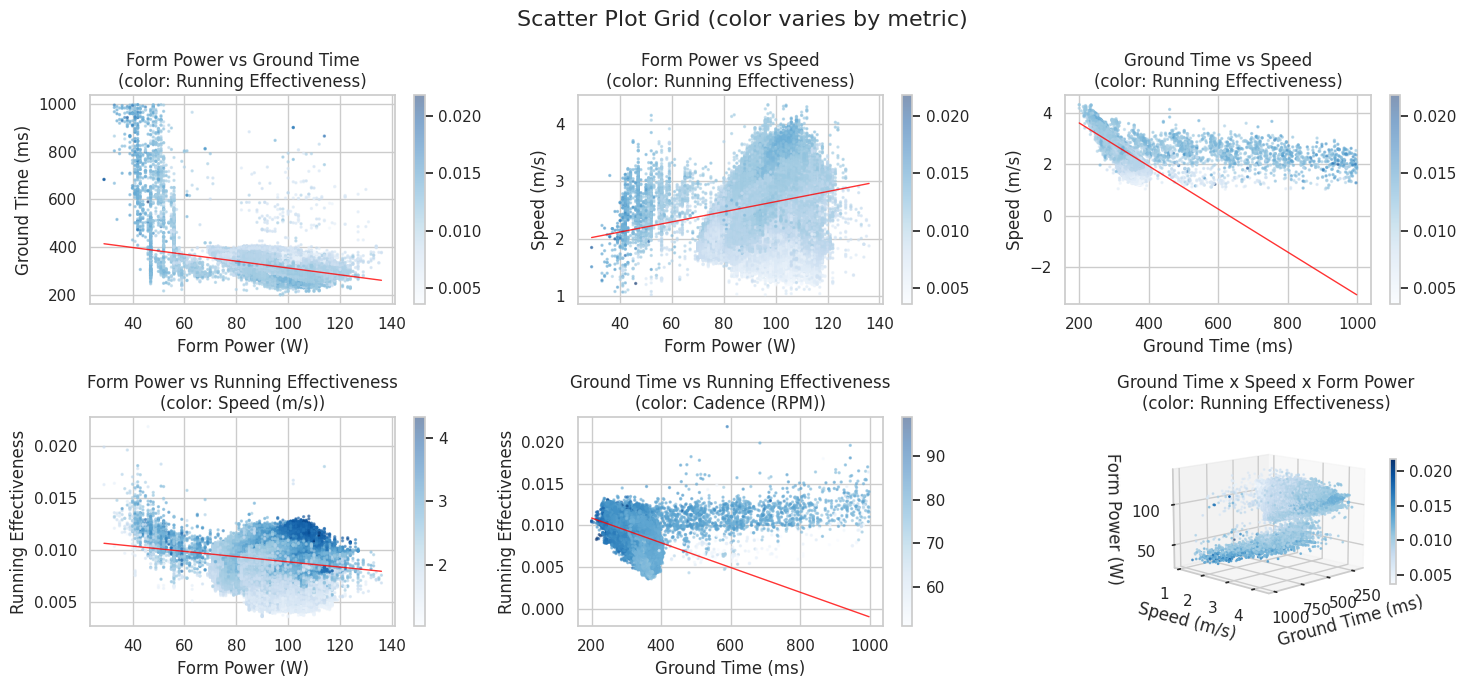

In [17]:
alpha = 0.5

def add_regression_line(ax, x, y, color="red"):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    slope, intercept = np.polyfit(x_clean, y_clean, 1)

    x_vals = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_vals = slope * x_vals + intercept

    ax.plot(x_vals, y_vals, color=color, linewidth=1, alpha=0.8)

fig, axs = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("Scatter Plot Grid (color varies by metric)", fontsize=16)

fp = run_df['Form Power']
gt = run_df["Ground Time"]
re = run_df["Running Effectiveness"]
es = run_df['Speed']
cc = run_df['Cadence']

# 1. Form Power vs Ground Time (color: Running Effectiveness)
ax = axs[0, 0]
sc = ax.scatter(fp, gt, c=re, s=2, alpha=alpha, cmap='Blues')
add_regression_line(ax, fp, gt)
ax.set_title("Form Power vs Ground Time\n(color: Running Effectiveness)")
ax.set_xlabel("Form Power (W)")
ax.set_ylabel("Ground Time (ms)")
fig.colorbar(sc, ax=ax)

# 2. Form Power vs enhanced_speed (color: Running Effectiveness)
ax = axs[0, 1]
sc = ax.scatter(fp, es, c=re, s=2, alpha=alpha, cmap='Blues')
add_regression_line(ax, fp, es)
ax.set_title("Form Power vs Speed\n(color: Running Effectiveness)")
ax.set_xlabel("Form Power (W)")
ax.set_ylabel("Speed (m/s)")
fig.colorbar(sc, ax=ax)

# 3. Ground Time vs enhanced_speed (color: Running Effectiveness)
ax = axs[0, 2]
sc = ax.scatter(gt, es, c=re, s=2, alpha=alpha, cmap='Blues')
add_regression_line(ax, gt, es)
ax.set_title("Ground Time vs Speed\n(color: Running Effectiveness)")
ax.set_xlabel("Ground Time (ms)")
ax.set_ylabel("Speed (m/s)")
fig.colorbar(sc, ax=ax)

# 4. Form Power vs Running Effectiveness (color: enhanced_speed)
ax = axs[1, 0]
sc = ax.scatter(fp, re, c=es, s=2, alpha=alpha, cmap='Blues')
add_regression_line(ax, fp, re)
ax.set_title("Form Power vs Running Effectiveness\n(color: Speed (m/s))")
ax.set_xlabel("Form Power (W)")
ax.set_ylabel("Running Effectiveness")
fig.colorbar(sc, ax=ax)

# 5. Ground Time vs Running Effectiveness (color: cadence)
ax = axs[1, 1]
sc = ax.scatter(gt, re, c=cc, s=2, alpha=alpha, cmap='Blues')
add_regression_line(ax, gt, re)
ax.set_title("Ground Time vs Running Effectiveness\n(color: Cadence (RPM))")
ax.set_xlabel("Ground Time (ms)")
ax.set_ylabel("Running Effectiveness")
fig.colorbar(sc, ax=ax)

# 6. Hide the last subplot
axs[1, 2].axis("off")

# 6. 3D scatter plot
ax3d = fig.add_subplot(2, 3, 6, projection='3d')
sc = ax3d.scatter(
    gt,
    es,
    fp,
    c=re,
    s=1,
    cmap="Blues"
)

ax3d.set_title("Ground Time x Speed x Form Power\n(color: Running Effectiveness)")

ax3d.set_xlabel("Ground Time (ms)")
ax3d.set_ylabel("Speed (m/s)")
ax3d.set_zlabel("Form Power (W)")
ax3d.view_init(elev=12, azim=45)

fig.colorbar(sc, ax=ax3d, shrink=0.6)

plt.tight_layout()
plt.show()

Scatter plots show the relationships across all data points.  
They reveal the actual distribution. 
The most important thing is that running data can be clustered.
The most dense area in the scatter plots is running and the other may be jogging or other non-focused running.

- Low Form Power (\< 70 W) leads high ground time (\> 400 ms). Actual running data concentrate on Form Power \> 70 W. Form Power more than 70 W weakly correlates to Ground Time. (Upper left chart)
- Low Form Power (\< 70 W) tends to have low speed but not apparent difference in terms of speed. (Upper middle chart)
- Plots concentrate on Ground Time under 400 ms. Strong negative correlation appears. (Upper right chart)
- Form Power doesn't apparently relates to Running Effectiveness. (Lower left chart)
- Ground Time has negative correlation to Running Effectiveness. (Lower middle chart)

The lower right 3D scatter plot shows that the data points can be apparently separated to 2 groups. Lower Form Power group may be jogging and the higher one may be actual running.


In [18]:
#run_df.select_dtypes(include=np.number).corr()

## 7. Focus on Actual Running Activity

Focus on actual running data.
First, clusterize with HDBSCAN.

In [19]:
features = ["Form Power", "Ground Time", "Speed"]
X = run_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
run_df["cluster"] = clusterer.fit_predict(X_scaled)


In [20]:
run_df['cluster'].value_counts()


cluster
 2    475763
-1      2451
 1       215
 0       119
Name: count, dtype: int64

It clusterized the datapoints into 3 clusters.

In this data and the preceding 3D scatter plot, most densed cluster 2 is the running data.
Let's see the distribution with cluster colors.

In [ ]:
alpha = 0.3

fig, axs = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("Scatter Plot Grid (color by cluster)", fontsize=16)
c = run_df['cluster']
cmap = 'tab10'

re_alpha = (re - re.min()) / (re.max() - re.min())
re_alpha *= re_alpha
alpha = re_alpha
# 1. Form Power vs Ground Time
ax = axs[0, 0]
sc = ax.scatter(run_df["Form Power"], run_df["Ground Time"],
                c=c, s=2, alpha=alpha, cmap=cmap)
ax.set_title("Form Power vs Ground Time")
ax.set_xlabel("Form Power (W)")
ax.set_ylabel("Ground Time (ms)")

# 2. Form Power vs enhanced_speed
ax = axs[0, 1]
sc = ax.scatter(run_df["Form Power"], run_df["Speed"],
                c=c, s=2, alpha=alpha, cmap=cmap)
ax.set_title("Form Power vs Speed")
ax.set_xlabel("Form Power (W)")
ax.set_ylabel("Speed (m/s)")

# 3. Ground Time vs enhanced_speed
ax = axs[0, 2]
sc = ax.scatter(run_df["Ground Time"], run_df["Speed"],
                c=c, s=2, alpha=alpha, cmap=cmap)
ax.set_title("Ground Time vs Speed")
ax.set_xlabel("Ground Time (ms)")
ax.set_ylabel("Speed (m/s)")


# 4. Form Power vs Running Effectiveness
es_alpha = (es - es.min()) / (es.max() - es.min())
es_alpha *= es_alpha
alpha = es_alpha
ax = axs[1, 0]
sc = ax.scatter(run_df["Form Power"], run_df["Running Effectiveness"],
                c=c, s=2, alpha=alpha, cmap=cmap)
ax.set_title("Form Power vs Running Effectiveness")
ax.set_xlabel("Form Power (W)")
ax.set_ylabel("Running Effectiveness")

# 5. Ground Time vs Running Effectiveness
cc_alpha = (cc - cc.min()) / (cc.max() - cc.min())
cc_alpha *= cc_alpha
alpha = 0.3
ax = axs[1, 1]
sc = ax.scatter(run_df["Ground Time"], run_df["Running Effectiveness"],
                c=c, s=2, alpha=alpha, cmap=cmap)
ax.set_title("Ground Time vs Running Effectiveness")
ax.set_xlabel("Ground Time (ms)")
ax.set_ylabel("Running Effectiveness")

# 6. Hide the last subplot
axs[1, 2].axis("off")

# 6. 3D scatter plot
ax3d = fig.add_subplot(2, 3, 6, projection='3d')

feature_x = "Ground Time"
feature_y = "Speed"
feature_z = "Form Power"
feature_c = "Running Effectiveness"

alpha = (re - re.min()) / (re.max() - re.min())
alpha *= alpha

sc = ax3d.scatter(
    run_df[feature_x],
    run_df[feature_y],
    run_df[feature_z],
    c=c,
    s=1,
    alpha=alpha,
    cmap=cmap
)

ax3d.set_title("Ground Time x Speed x Form Power")
ax3d.set_xlabel("Ground Time (ms)")
ax3d.set_ylabel("Speed (m/s)")
ax3d.set_zlabel("Form Power (W)")
ax3d.view_init(elev=12, azim=45)

plt.tight_layout()
plt.show()


In [ ]:
# (cc - cc.min()) / (cc.max() - cc.min())

Now, most running data is correctly clusterd.

The multiple distinct clusters suggests that the overall correlation structure is a mixture of different movement patterns.
In other words, correlations we calculeted bofore may change in the cluster focused analysis.

Then, I compute correlations separately for the running cluster to isolate the relationships relevant to performance improvement.

In the following heatmap shows correlations in all data and ones in clustered data can be different.

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fig.suptitle("Correlations", fontsize=16)

corr_matrix = run_df[corr_features].corr()
sns.heatmap(
    corr_matrix, annot=True, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, fmt=".2f",
    # cbar_kws={'label': 'Pearson Correlation'},
    cbar=None,
    ax=axs[0]
)
axs[0].set_title("All Data")

cluster_df = run_df[run_df['cluster'] == 2]
clustered_corr_matrix = cluster_df[corr_features].corr()
sns.heatmap(
    clustered_corr_matrix, annot=True, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, fmt=".2f",
    cbar_kws={'label': 'Pearson r'},
    # cbar=None,
    ax=axs[1]
)
# axs[1].tick_params(axis='y', left=False, labelleft=False)
axs[1].set_yticks([])
axs[1].set_ylabel("")
axs[1].set_title("Clustered Data")
# plt.tight_layout()
fig.subplots_adjust(wspace=0.1)

plt.show()

The cluster focused correlations shows that **Ground Time is more highly correlated to Running Effectiveness** than we calculated before, and **Form Power** shows less relation.

Now we can say:

- The most strongly related metrics to Running Effectiveness are Leg Spring Stiffness, Speed, and Ground Time. 
- Form power and Power are not strongly related to Running Effectiveness.

It also means that the effectiveness of metrics in running activity are changed from the ones in jogging.
Practically speaking, Form power and Power don't have so much change and effect on Running Effectiveness. 

To improve Running Effectiveness, Leg Spring Stiffness, Speed, and Ground Time are the candidate to control.
But Leg Spring Stiffness is a metrics calculated based on other device numbers.
Dr. Jaén-Carrillo and Dr. Cartón-Llorente wrote "The Stryd sensor provides valid leg stiffness estimates in highly trained trail runners on both level and inclined terrain" (Jaén-Carrillo and Cartón-Llorente, 2026).
So it is not good for target to change.
Also, Speed is a result of multiple body activities.
Ground Time is a good one under runners' control.

Ground Time of elite runners are in the range of 155-175 ms, according to Figure 2 in _Ground contact time as an indicator of metabolic cost in elite distance runners_ (Chapman et al., 2012). Also wrote elite distance runners' Ground Time is frequently under 200 ms (Mayer, 2024).

According to the line chart, Dr. Brooks' Ground Time median drop in 260-300 ms in the latter sessions.
Let's see the detail distribution of the data in 2020.

In [ ]:
detail_df = cluster_df[cluster_df['timestamp'] >= datetime(2020, 1, 1)]
plt.title('Term 3 Ground Time (ms)')
plt.scatter(detail_df['timestamp'], detail_df['Ground Time'], c=detail_df['cluster'], s=1, cmap='tab10', alpha=0.1)
plt.axhline(
    y=300,
    color='red',
    linewidth=1,
    alpha=0.8
)

After Sep. in 2020, the Ground Time data are around 300 ms.

## Conclusion

I reviewed the running data, except for jogging or other irregular data, in the given data.

From 2019 to 2020, Dr. Brooks running is improved through ground time reduction.
It is concluded by running effectiveness improvement.
It is the value of speed divided by power, which are in the given data.

Ground Time shows a strong negative relationship with speed.  
It also strongly affects Running Effectiveness.  
On the other hand, Form Power is less related.

Therefour, I propose to improve ground time for better running effectiveness.
To improve running effectiveness more, Gound Time can be improved.
The data shows Dr. Brooks' ground time in 2020 is around 300 ms, and elete athletes' are mostly under 200 ms (Mayer, 2024).
His ground time can be more shorter and it leads to improvement of running effectiveness.

Body improvement requires time and I recommend to make ground time under 350, at first.

## Interactive Dashboard: Exploring Dr. Brooks' Running Performance

I have developed a dashboard for deep exploration.
The dashboard combines four primary filtering:

- a date range
- ground contact time (milliseconds)
- running effectiveness (speed/power)
- running speed
- running cluster (fucused running or other running)

The filtered data is presented in three coordinated scatter plots, colored by running effectiveness.

- Form power vs. ground contact time
- form power vs. speed
- ground contact time vs. speed

These visualizations helps to observe multivariate patterns that a single static analysis could not capture.

In [ ]:

min_date = run_df['timestamp'].min()
max_date = run_df['timestamp'].max()

min_gt = run_df['Ground Time'].min()
max_gt = run_df['Ground Time'].max()

min_re = run_df['Running Effectiveness'].min()
max_re = run_df['Running Effectiveness'].max()

min_speed = run_df['Speed'].min()
max_speed = run_df['Speed'].max()

min_fp = run_df['Form Power'].min()
max_fp = run_df['Form Power'].max()

In [ ]:

min_ts = run_df['timestamp'].min()
max_ts = run_df['timestamp'].max()

min_date = min_ts.date()
max_date = max_ts.date()

desc_width = '150px'

days_total = (max_date - min_date).days

date_slider = widgets.IntRangeSlider(
    value=(0, days_total),
    min=0,
    max=days_total,
    step=1,
    description='Date',
    layout={'width': '600px'},
    readout=False,
    style={'description_width': desc_width}
)

start_picker = widgets.DatePicker(
    description='Start',
    layout={'width': '220px'},
    style={'description_width': '80px'}
)
end_picker   = widgets.DatePicker(
    description='End',
    layout={'width': '220px'},
    style={'description_width': '80px'}
)
start_picker.value = min_date
end_picker.value   = max_date

def slider_to_picker(change):
    start_picker.value = int_to_date(date_slider.value[0])
    end_picker.value   = int_to_date(date_slider.value[1])

def picker_to_slider(change):
    if start_picker.value and end_picker.value:
        date_slider.value = (
            (start_picker.value - min_date).days,
            (end_picker.value - min_date).days
        )

def int_to_date(n):
    return min_date + timedelta(days=int(n))

def update_date_readout(change):
    start = int_to_date(date_slider.value[0])
    end   = int_to_date(date_slider.value[1])
    date_slider.readout = f"{start} - {end}"

# update_date_readout(None)
# date_slider.observe(update_date_readout, names='value')
date_slider.observe(slider_to_picker, names='value')
start_picker.observe(picker_to_slider, names='value')
end_picker.observe(picker_to_slider, names='value')

gt_slider = widgets.IntRangeSlider(
    value=(min_gt, max_gt),
    min=min_gt,
    max=max_gt,
    step=0.1,
    description='Ground Time',
    layout={'width': '600px'},
    style={'description_width': desc_width}
)

re_slider = widgets.FloatRangeSlider(
    value=(min_re, max_re),
    min=min_re,
    max=max_re,
    step=0.1,
    description='Running Effectiveness',
    layout={'width': '600px'},
    style={'description_width': desc_width}
)

speed_slider = widgets.FloatRangeSlider(
    value=(min_speed, max_speed),
    min=min_speed,
    max=max_speed,
    step=0.01,
    description='Speed',
    layout={'width': '600px'},
    style={'description_width': desc_width}
)

cluster_label = widgets.HTML(
    "<div style='width:150px; text-align:right;'>Cluster Options</div>"
)
running_cluster = widgets.Checkbox(
    value=True,
    description='Focused Running Cluster',
    style={'description_width': '0px'}
)
other_cluster   = widgets.Checkbox(
    value=True,
    description='Unfocused Running Clusters',
    style={'description_width': desc_width}
)
cluster_ui = widgets.VBox([
    widgets.HBox([cluster_label, running_cluster]),
    widgets.HBox([widgets.Label(""), other_cluster])
])

def show_dashboard(start_date, end_date,
                   gt_range, re_range, speed_range,
                   use_cluster2, use_other):

    # start_date = int_to_date(date_range[0])
    # end_date   = int_to_date(date_range[1])
    
    filtered_df = run_df.copy()

    filtered_df = filtered_df[
        (filtered_df['timestamp'].dt.date >= start_date) &
        (filtered_df['timestamp'].dt.date <= end_date)
    ]

    filtered_df = filtered_df[
        (filtered_df['Ground Time'] >= gt_range[0]) &
        (filtered_df['Ground Time'] <= gt_range[1])
    ]

    filtered_df = filtered_df[
        (filtered_df['Running Effectiveness'] >= re_range[0]) &
        (filtered_df['Running Effectiveness'] <= re_range[1])
    ]

    filtered_df = filtered_df[
        (filtered_df['Speed'] >= speed_range[0]) &
        (filtered_df['Speed'] <= speed_range[1])
    ]

    # cluster filter
    if use_cluster2 and not use_other:
        filtered_df = filtered_df[filtered_df['cluster'] == 2]
    elif use_other and not use_cluster2:
        filtered_df = filtered_df[filtered_df['cluster'] != 2]
    # if both True or both False -> no filtering

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Scatter Plots (color: Running Effectiveness)", fontsize=16)

    alpha = 0.5

    ffp = filtered_df['Form Power']
    fgt = filtered_df["Ground Time"]
    fre = filtered_df["Running Effectiveness"]
    fes = filtered_df['Speed']
    fcc = filtered_df['Cadence']

    # 1. FP vs GT
    ax = axs[0]
    sc = ax.scatter(ffp, fgt, c=fre, s=2, alpha=alpha, cmap='Blues', vmin=min_re, vmax=max_re)
    add_regression_line(ax, ffp, fgt)
    ax.set_title("Form Power vs Ground Time")
    ax.set_xlabel("Form Power (W)")
    ax.set_xlim(min_fp - (max_fp - min_fp) * 0.05, max_fp + (max_fp - min_fp) * 0.05)
    ax.set_ylabel("Ground Time (ms)")
    ax.set_ylim(min_gt - (max_gt - min_gt) * 0.05, max_gt + (max_gt - min_gt) * 0.05)
    fig.colorbar(sc, ax=ax)

    # 2. FP vs Speed
    ax = axs[1]
    sc = ax.scatter(ffp, fes, c=fre, s=2, alpha=alpha, cmap='Blues', vmin=min_re, vmax=max_re)
    add_regression_line(ax, ffp, fes)
    ax.set_title("Form Power vs Speed")
    ax.set_xlabel("Form Power (W)")
    ax.set_xlim(min_fp - (max_fp - min_fp) * 0.05, max_fp + (max_fp - min_fp) * 0.05)
    ax.set_ylabel("Speed (m/s)")
    ax.set_ylim(min_speed - (max_speed - min_speed) * 0.05, max_speed + (max_speed - min_speed) * 0.05)
    fig.colorbar(sc, ax=ax)

    # 3. GT vs Speed
    ax = axs[2]
    sc = ax.scatter(fgt, fes, c=fre, s=2, alpha=alpha, cmap='Blues', vmin=min_re, vmax=max_re)
    add_regression_line(ax, fgt, fes)
    ax.set_title("Ground Time vs Speed")
    ax.set_xlabel("Ground Time (ms)")
    ax.set_xlim(min_gt - (max_gt - min_gt) * 0.05, max_gt + (max_gt - min_gt) * 0.05)
    ax.set_ylabel("Speed (m/s)")
    ax.set_ylim(min_speed - (max_speed - min_speed) * 0.05, max_speed + (max_speed - min_speed) * 0.05)
    fig.colorbar(sc, ax=ax)

    plt.tight_layout()
    plt.show()


ui = widgets.VBox([
    date_slider,
    widgets.HBox([
        widgets.HTML("<div style='width:150px; text-align:right;'></div>"),
        start_picker,
        end_picker
    ]),
    gt_slider,
    re_slider,
    speed_slider,
    cluster_ui
])

def get_date_range():
    return (start_picker.value, end_picker.value)

out = widgets.interactive_output(
    show_dashboard,
    {
        'start_date': start_picker,
        'end_date': end_picker,
        'gt_range': gt_slider,
        're_range': re_slider,
        'speed_range': speed_slider,
        'use_cluster2': running_cluster,
        'use_other': other_cluster
    }
)

display(ui, out)

## References

- Chapman, R. F., Laymon, A. S., Wilhite, D. P., McKenzie, J. M., Tanner, D. A., & Stager, J. M. (2012). Ground contact time as an indicator of metabolic cost in elite distance runners. *Medicine & Science in Sports & Exercise, 44*(5), 917–925. https://doi.org/10.1249/MSS.0b013e3182400520
- from1runner2another. (2026, May 22). *What is running effectiveness?*. https://f1r2a.com/what/what-is-running-effectiveness-2605/
- Jaén-Carrillo, D., & Cartón-Llorente, A. (2026). The validity of Stryd leg stiffness against the Morin (2005) sine-wave method: A level-1 assessment of flat and uphill treadmill running. *Sensors, 26*(10), 3244. https://doi.org/10.3390/s26103244
- Mayer, A. (2024, April 29). *Ground contact time: What it means + how to improve*. Marathon Handbook. https://marathonhandbook.com/ground-contact-time/
- Rougier, N. P., Droettboom, M., & Bourne, P. E. (2014). Ten simple rules for better figures. *PLoS Computational Biology, 10*(9), e1003833. https://doi.org/10.1371/journal.pcbi.1003833
- Rule, A., Birmingham, A., Zuniga, C., Altintas, I., Huang, S.-C., Knight, R., Moshiri, N., Nguyen, M. H., Rosenthal, S. B., Pérez, F., & Rose, P. W. (2019). *Ten simple rules for writing and sharing computational analyses in Jupyter Notebooks*. PLOS Computational Biology, 15(7), e1007007. https://doi.org/10.1371/journal.pcbi.1007007